<center>


<div style="display: flex; justify-content: center;">
    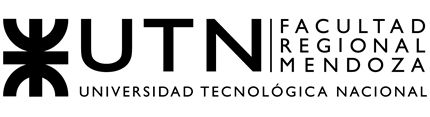
</div>
</center>
<center>
    <div style="font-family: 'Georgia', serif; font-size: 24px;">
        <p><strong>Análisis de Señales y Sistemas</strong></p>
        <p><strong>Departamento de Ingeniería en Tecnologías Electrónicas</strong></p>
    </div>
</center>

# Laboratorio n° 3: Muestreo

**Asignatura:** Análisis de Señales y Sistemas
**Requisitos previos:** Módulos 1 a 9, Laboratorio 0, Laboratorio 1 y Laboratorio 2

---

## Introducción

Hay un número que viene apareciendo desde el Laboratorio 1 sin ninguna explicación: **44100**. Es la frecuencia de muestreo de los audios que sintetizaste y de los que leíste de un archivo. En el Laboratorio 2 incluso verificaste que las dos señales a convolucionar la compartieran, con el argumento de que si no coincidían el cálculo no tenía sentido físico. Pero nunca se dijo de dónde sale ese número, quién lo eligió, ni qué pasa si se elige mal.

Ese es el tema de este laboratorio. Una señal física —la presión del aire durante una nota de violín, la tensión en un capacitor— existe en **todos** los instantes: entre dos momentos cualesquiera, por próximos que sean, hay infinitos momentos más. Una computadora no puede guardar infinitos números. Lo que guarda es una **lista finita de valores**, tomados a intervalos regulares. A ese procedimiento se lo llama **muestreo**, y la pregunta que ordena todo el laboratorio es una sola:

> ¿Cuánta información se pierde al quedarse solo con esas muestras, y de qué depende?

La respuesta no es "siempre se pierde un poco". Es mucho más interesante: si las muestras se toman **suficientemente seguido**, no se pierde absolutamente nada, y la señal original se puede reconstruir de manera exacta a partir de la lista de números. Si se toman demasiado espaciadas, en cambio, lo que se pierde no es un poco de detalle: aparecen frecuencias que **nunca estuvieron en la señal original**, un fenómeno llamado **aliasing**. Vas a poder escucharlo.

Un aviso sobre el alcance. La explicación completa del aliasing se apoya en herramientas de análisis en frecuencia que todavía no manejamos; ese es el tema del Laboratorio 4. Acá el fenómeno se aborda enteramente **en el dominio del tiempo**: se predice con una cuenta sencilla, se verifica gráficamente muestra por muestra y se comprueba de oído. Es un orden deliberado: primero se escucha lo que pasa, después se explica por qué.

Al completar este laboratorio vas a poder:

- Explicar la relación entre frecuencia de muestreo, intervalo entre muestras y cantidad de muestras, y construir un eje de tiempo correcto para una señal muestreada.
- Distinguir entre reconstruir una señal y limitarse a dibujarla, y describir qué supone cada método de reconstrucción.
- Predecir la **frecuencia aparente** de una señal submuestreada y verificar la predicción de manera gráfica y auditiva.
- Enunciar el criterio de Nyquist, aplicarlo y explicar por qué la desigualdad es estricta.
- Aplicar un filtro **antialiasing** antes de reducir la frecuencia de muestreo y evaluar qué mejora y qué se pierde.

---

## Instrucciones generales

- Completá el código en las celdas marcadas con `# Tu código aquí`.
- Respondé las preguntas de análisis en las celdas de texto (tipo Markdown).
- Ejecutá las celdas en orden: varios ejercicios reutilizan variables y funciones definidas en ejercicios anteriores.
- Varios ejercicios generan sonido. Si estás en un entorno sin audio, los gráficos alcanzan para resolverlos, pero conviene escucharlos: buena parte de este laboratorio se entiende mejor con los oídos que con los ojos.

## IMPORTANTE: qué celdas podés modificar

Este laboratorio es un **entregable**. Solo debés completar las celdas de actividad, que son las que aparecen con el comentario `# Tu código aquí` o el texto `*(Escribí tu respuesta acá)*`. Todas las demás celdas (enunciados, explicaciones, ejemplos provistos y el encabezado) **no deben modificarse**: la corrección se hace celda por celda de manera automática y alterar lo que no corresponde puede invalidar tu entrega.

Si necesitás probar algo fuera de una celda de actividad, hacelo en una copia aparte y revertí los cambios antes de entregar.

---
## Preparación

Ejecutá las dos celdas que siguen **una sola vez** al empezar.

La primera importa las librerías. Son las mismas del Laboratorio 2, sin las de imágenes: NumPy, Matplotlib, la lectura de archivos `.wav` de SciPy y el reproductor de audio de Colab.

La segunda descarga la grabación de violín que vas a usar en el último ejercicio. Si ya está descargada, no vuelve a bajarla.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Lectura de archivos .wav, igual que en el Laboratorio 2.
from scipy.io.wavfile import read

# Reproducción de audio dentro del notebook, igual que en los Laboratorios 1 y 2.
from IPython.display import Audio

print(f"Versión de NumPy: {np.__version__}")

In [ ]:
import os
import urllib.request

URL_BASE = "https://raw.githubusercontent.com/ASyS-utn-frm/python/main/resources/audios/"
ARCHIVOS = ("violin.wav",)

os.makedirs("audios", exist_ok=True)

for nombre in ARCHIVOS:
    destino = os.path.join("audios", nombre)
    if not os.path.exists(destino):
        urllib.request.urlretrieve(URL_BASE + nombre, destino)
    print(f"{destino}: {os.path.getsize(destino) / 1024:.0f} kB")

---
## Sección A: De la señal continua a la lista de números

Muestrear una señal es quedarse con su valor en instantes separados por un intervalo fijo. Ese intervalo se llama **período de muestreo** y se anota $T_s$; su inversa es la **frecuencia de muestreo**,

$$f_s = \frac{1}{T_s}$$

y se mide en hertz, es decir en muestras por segundo. Si se muestrea una señal durante $D$ segundos a una frecuencia $f_s$, la cantidad de muestras que se obtienen es

$$N = D \cdot f_s$$

Estas tres cantidades —intervalo, frecuencia y cantidad de muestras— son la misma información escrita de tres maneras, y conviene poder pasar de una a otra sin pensarlo.

**Cómo construir el eje de tiempo.** La muestra de índice $n$ se tomó en el instante $t_n = n / f_s$. En NumPy eso se escribe directamente:

```
n = np.arange(N)
t = n / fs
```

Este laboratorio usa siempre esta forma y **no** `np.linspace`. La razón es la que apareció en el Laboratorio 1: `linspace` incluye por omisión los dos extremos del intervalo, de modo que el último instante queda a una distancia distinta del anterior y el espaciado deja de ser exactamente $1/f_s$. Con `np.arange(N) / fs` el espaciado es correcto por construcción.

**Una advertencia sobre la palabra "continua".** En este laboratorio vas a comparar señales muestreadas contra una señal "continua" de referencia. Esa referencia también es una lista de números: no hay otra cosa en una computadora. Lo que la hace servir como referencia es que está muestreada **mucho** más seguido que las señales bajo estudio —cientos de muestras por período en lugar de unas pocas—, tan seguido que al dibujarla la línea se ve como una curva suave y ninguna de las conclusiones del laboratorio cambiaría si se la muestreara todavía más seguido. Es una aproximación deliberada y es importante no confundirla con lo real.

### Ejercicio 1 — La misma señal, cuatro frecuencias de muestreo

**Objetivo:** Construir correctamente el eje de tiempo de una señal muestreada y observar cómo cambia lo que las muestras registran al espaciarlas cada vez más.

Vamos a trabajar con una señal sencilla y perfectamente conocida: una senoide de **5 Hz** de amplitud 1, observada durante **1 segundo**. Al ser conocida, cualquier discrepancia entre lo que vemos y lo que sabemos que hay es atribuible al muestreo y no a la señal.

**Enunciado:**

1. Definí `f_senal = 5.0` y `duracion = 1.0`.
2. Construí la señal de referencia con `fs_ref = 5000` Hz: calculá la cantidad de muestras, el eje `t_ref` y la señal `x_ref = np.sin(2 * np.pi * f_senal * t_ref)`.
3. Para cada una de las frecuencias de muestreo `200`, `50`, `20` y `7` Hz, muestreá la **misma** señal: construí su eje de tiempo y sus muestras.
4. Para cada frecuencia, imprimí en una línea: la frecuencia de muestreo, el intervalo entre muestras $T_s$ en milisegundos, la cantidad de muestras obtenidas y cuántas muestras por período de la señal representa eso.
5. Graficá las cuatro en cuatro paneles, uno debajo del otro y con el eje horizontal compartido. En cada panel dibujá **la referencia como una línea** y **las muestras como puntos** sobre ella. Cada panel con su título, etiquetas en los ejes y grilla.

> **Pista 1:** la cantidad de muestras se obtiene con `int(round(duracion * fs))`. Se redondea porque el producto puede dar un valor como `199.99999` por la representación de los números con decimales.
>
> **Pista 2:** para superponer líneas y puntos en el mismo panel, dibujá primero la referencia con `axs[i].plot(...)` y encima las muestras con `axs[i].plot(t, x, "o")`. El `"o"` es el atajo estilo MATLAB del Módulo 8 para marcar cada dato con un círculo sin unirlos con líneas.
>
> **Pista 3:** el eje horizontal compartido entre paneles se consigue con `plt.subplots(4, 1, figsize=(10, 10), sharex=True)`, como en el Laboratorio 1.
>
> **Pista 4:** las muestras por período son `fs / f_senal`.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

Respondé las dos partes:

1. Las cuatro listas de muestras son correctas: cada punto vale exactamente lo que vale la senoide en ese instante, y ninguna operación introdujo error. Sin embargo, mirando solamente los puntos rojos, el panel de 200 Hz permite reconocer la señal y el de 7 Hz no. Explicá qué es lo que se perdió, teniendo en cuenta que ningún valor está mal.
2. En el panel de 7 Hz los puntos rojos no quedan desordenados: se acomodan sobre una oscilación clara, más lenta que la original, de aproximadamente 2 Hz. Sin hacer todavía ninguna cuenta, describí qué problema práctico representa eso para alguien que reciba únicamente la lista de muestras y no la señal original.

*(Escribí tu respuesta acá)*

### Dibujar no es reconstruir

En el gráfico anterior las muestras se dibujaron como puntos sueltos, que es lo que honestamente son. Pero para volver a tener una señal —para escucharla por un parlante, para aplicarla a un circuito— hay que decidir qué valor tiene entre una muestra y la siguiente. Ese paso se llama **reconstrucción** y siempre involucra una suposición.

Dos maneras habituales, que vas a comparar en el ejercicio 2:

- **Interpolación lineal:** entre dos muestras consecutivas se traza un segmento de recta. Es exactamente lo que hace `plt.plot` cuando une los datos, y es la razón por la que en el Módulo 8 se advirtió que Matplotlib "conecta muestras": el dibujo ya es una reconstrucción, aunque uno no la haya pedido.
- **Retención de orden cero:** el valor se mantiene constante desde una muestra hasta la siguiente, y ahí salta. Es lo que hace físicamente un conversor digital-analógico común, y se dibuja con `plt.step(t, x, where="post")`. El argumento `where="post"` indica que el escalón se mantiene **después** de cada muestra, que es el orden temporal correcto.

Ninguna de las dos es la reconstrucción óptima. La reconstrucción exacta existe —cuando el muestreo cumple la condición que vas a ver en la sección C, la señal original se recupera **sin ningún error**—, pero la fórmula que la produce necesita herramientas del Laboratorio 4. Lo que importa acá es notar que hay una decisión tomada en cada gráfico, y que la calidad del resultado depende mucho más de cuántas muestras haya que de cuál de las dos reconstrucciones se elija.

### Ejercicio 2 — Dos reconstrucciones de las mismas muestras

**Objetivo:** Comparar interpolación lineal y retención de orden cero, y medir el error de cada una contra la señal de referencia.

Vas a trabajar sobre la misma senoide de 5 Hz del ejercicio 1, muestreada a **20 Hz**: 4 muestras por período, un caso incómodo pero no catastrófico.

**Enunciado:**

1. Recuperá el eje y las muestras de 20 Hz del ejercicio 1 (o volvé a construirlos) y guardalos en `t_20` y `x_20`.
2. Construí la reconstrucción **lineal** evaluada sobre el eje denso de referencia:
   ```
   x_lineal = np.interp(t_ref, t_20, x_20)
   ```
3. Construí la reconstrucción por **retención de orden cero** sobre el mismo eje denso. Para cada instante de `t_ref` hay que tomar el valor de la última muestra ya ocurrida, cuyo índice es `np.floor(t_ref * 20).astype(int)`. Acotá ese índice al último disponible con `np.clip(..., 0, x_20.size - 1)` y usalo para indexar `x_20`.
4. Graficá en un solo panel: la referencia, la reconstrucción lineal, la reconstrucción por retención de orden cero y las muestras como puntos. Título, etiquetas, grilla y leyenda.
5. Calculá e imprimí, para cada una de las dos reconstrucciones, el **error máximo** respecto de `x_ref`, es decir el mayor valor absoluto de la diferencia. Como la señal tiene amplitud 1, ese número se lee directamente como fracción de la amplitud.

   Considerá **solamente los instantes cubiertos por las muestras**, es decir aquellos en los que `t_ref <= t_20[-1]`. Más allá de la última muestra ninguno de los dos métodos está reconstruyendo: los dos se limitan a repetir el último valor disponible, porque no tienen con qué hacer otra cosa. Si se incluyera ese tramo final, lo que se estaría midiendo es esa extrapolación —que da un error cercano al 100 % en los dos casos— y no la calidad de la reconstrucción, que es lo que se quiere comparar.

> **Pista 1:** `np.interp(x_nuevo, x_conocido, y_conocido)` interpola linealmente: devuelve el valor que le corresponde a cada punto de `x_nuevo` según los datos conocidos.
>
> **Pista 2:** indexar un array con **otro array de índices enteros** devuelve un array con los valores correspondientes. Es la manera de construir la retención de orden cero sin ningún bucle.
>
> **Pista 3:** el error máximo entre dos arrays es `np.max(np.abs(a - b))`.
>
> **Pista 4:** para quedarte con el tramo cubierto por las muestras, construí una máscara booleana `valido = t_ref <= t_20[-1]` y usala para indexar los tres arrays, como en el ejercicio 8 del Laboratorio 1.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

Respondé las tres partes:

1. Las dos reconstrucciones parten de **exactamente las mismas cuatro muestras por período** y sin embargo dan errores distintos. Explicá de dónde sale esa diferencia y por qué la retención de orden cero es la peor de las dos.
2. La reconstrucción lineal pasa exactamente por cada muestra y aun así se aparta de la señal original. Explicá dónde se produce el error y por qué "pasar por todos los puntos" no alcanza para reconstruir bien.
3. Supongamos que se duplica la frecuencia de muestreo a 40 Hz. Indicá qué esperás que pase con cada uno de los dos errores y justificalo. No hace falta calcularlo.

*(Escribí tu respuesta acá)*

---
## Sección B: Aliasing

En el ejercicio 1 apareció algo que todavía no explicamos: muestreada a 7 Hz, la senoide de 5 Hz dejó sus muestras acomodadas sobre una oscilación de aproximadamente 2 Hz. No es una casualidad ni un defecto de la cuenta. Es un fenómeno con nombre propio, **aliasing**, y con una regla exacta que lo predice.

La regla es la siguiente. Al muestrear a $f_s$ una señal senoidal de frecuencia $f$, las muestras que se obtienen son **indistinguibles** de las que produciría una senoide de frecuencia

$$f_{ap} = \begin{cases} r & \text{si } r \le f_s/2 \\[4pt] f_s - r & \text{si } r > f_s/2 \end{cases} \qquad \text{con } r = f \bmod f_s$$

donde $f \bmod f_s$ es el resto de dividir $f$ por $f_s$. A $f_{ap}$ se la llama **frecuencia aparente**, y siempre queda entre $0$ y $f_s/2$.

Conviene leer la fórmula en dos pasos. El primero, el resto, dice que **sumarle $f_s$ a la frecuencia de una señal no cambia sus muestras**: las frecuencias $f$, $f + f_s$, $f + 2f_s$, … producen todas la misma lista de números. El segundo, el reemplazo de $r$ por $f_s - r$, dice que dentro de ese rango la mitad de arriba se **pliega** sobre la mitad de abajo, como una hoja de papel que se dobla por la mitad. De ahí el nombre de *folding* que suele darse a este efecto.

Verificalo contra el ejercicio 1: con $f = 5$ Hz y $f_s = 7$ Hz, el resto es $r = 5$, que es mayor que $f_s/2 = 3{,}5$, así que $f_{ap} = 7 - 5 = 2$ Hz. Es exactamente la oscilación que se veía.

La palabra *aliasing* viene de *alias*, sobrenombre: la señal se presenta con un nombre falso y no hay forma de descubrir el engaño mirando solamente las muestras. Los ejercicios que siguen recorren el fenómeno de tres maneras —gráfica, auditiva y como fórmula— para que quede claro que las tres describen lo mismo.

### Ejercicio 3 — Dos señales, las mismas muestras

**Objetivo:** Comprobar gráfica y numéricamente que dos señales de frecuencias distintas producen exactamente la misma lista de muestras.

Tomemos $f_s = 4$ Hz. Según la regla, una señal de 3 Hz tiene resto $r = 3 > 2$, así que su frecuencia aparente es $4 - 3 = 1$ Hz. Vamos a verificar que una senoide de 3 Hz y una de 1 Hz, muestreadas a 4 Hz, dan **los mismos números**.

**Enunciado:**

1. Definí `fs_alias = 4` y una duración de 2 segundos. Construí el eje `t_alias` de las muestras.
2. Construí las dos señales muestreadas, usando **coseno** en ambos casos: `x_3` de 3 Hz y `x_1` de 1 Hz, ambas evaluadas sobre `t_alias`.
3. Verificá con `np.allclose` que las dos listas de muestras coinciden e imprimí el resultado de la comparación, junto con las dos listas.
4. Construí las dos señales de referencia sobre un eje denso de 2000 Hz, para poder dibujarlas como curvas.
5. Graficá en un solo panel: la referencia de 3 Hz, la referencia de 1 Hz y las muestras compartidas como puntos. Título, etiquetas, grilla y leyenda.
6. Calculá la frecuencia aparente de la señal de 3 Hz aplicando la fórmula a mano —con el operador `%` de Python— e imprimila.

> **Pista 1:** el operador `%` calcula el resto: `3 % 4` da `3`.
>
> **Pista 2:** los puntos tienen que verse por encima de las dos curvas. Dibujá las curvas primero y las muestras al final, con un marcador grande: `plt.plot(t_alias, x_3, "o", markersize=9)`.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

Mirando el gráfico, la curva de 3 Hz pasa por los puntos rojos, y la de 1 Hz también. Explicá por qué esto **no** es un problema de precisión que se resolvería midiendo mejor, sino una ambigüedad de fondo. En tu respuesta indicá qué información adicional, además de la lista de muestras y del valor de $f_s$, haría falta para decidir cuál de las dos señales fue la que realmente se muestreó.

*(Escribí tu respuesta acá)*

### Ejercicio 4 — Aliasing que se escucha

**Objetivo:** Comprobar de oído que una señal submuestreada suena como su frecuencia aparente y no como la original.

El gráfico del ejercicio anterior es convincente pero silencioso. Acá el mismo fenómeno se vuelve audible: un tono de **3000 Hz** —agudo, del orden del silbido de un aparato electrónico— muestreado a 4000 Hz suena como uno de 1000 Hz, bastante más grave. La cuenta es la misma del ejercicio 3, multiplicada por mil.

**Enunciado:**

1. Definí `f_tono = 3000` y una duración de 2 segundos, y una amplitud `A = 0.5`.
2. Generá el tono muestreado **correctamente**, con `fs_ok = 32000` Hz, usando coseno. Reproducilo con `Audio(..., rate=fs_ok, normalize=False)`.
3. Generá el **mismo** tono de 3000 Hz muestreado a `fs_mal = 4000` Hz. Reproducilo con `rate=fs_mal`.
4. Generá un tono de 1000 Hz muestreado también a 4000 Hz y reproducilo.
5. Verificá con `np.allclose` que las muestras del punto 3 y las del punto 4 son iguales, e imprimí el resultado.
6. Graficá los primeros 5 milisegundos de las tres señales en tres paneles con el eje horizontal compartido, dibujando la señal correcta como línea y las dos submuestreadas como puntos unidos por líneas.

> **Pista 1:** en los Laboratorios 1 y 2 el reproductor aparecía porque `Audio(...)` era la **última** expresión de la celda, y una celda muestra solamente esa. Acá hacen falta tres reproductores en una sola celda, así que ese recurso no alcanza. La herramienta para eso es `display()`: importala con `from IPython.display import display` y escribí `display(Audio(...))` en cada caso. Así se muestran los tres, en el orden en que los pidas.
>
> **Pista 2:** recordá lo visto en el Laboratorio 1: `normalize=False` es necesario para que la amplitud que elegiste sea la que efectivamente se escucha, y exige que todos los valores estén entre −1 y 1.
>
> **Pista 3:** para quedarte con los primeros 5 ms de una señal muestreada a `fs`, usá `slicing` hasta la muestra `int(0.005 * fs)`.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

Respondé las dos partes:

1. Los tres reproductores suenan: el primero agudo y los otros dos idénticos entre sí y más graves. Explicá por qué el segundo suena igual que el tercero y no como el primero, si el segundo se generó a partir de la **misma** fórmula que el primero y con la misma frecuencia.
2. Un sistema de adquisición cualquiera —una placa de sonido, un osciloscopio digital, un sensor con salida digital— entrega solamente números. Explicá por qué el aliasing es especialmente peligroso en ese contexto, comparado con otras degradaciones como el ruido o la saturación, e indicá en qué momento de la cadena de medición hay que actuar para evitarlo.

*(Escribí tu respuesta acá)*

### La regla completa, escrita como función

Los dos ejercicios anteriores confirmaron la regla en casos aislados. El ejercicio 5 la escribe como una función de Python y la aplica a un rango completo de frecuencias, para ver de una sola vez qué le pasa a cada una.

La cuenta es la de la introducción de la sección: primero el resto de dividir por $f_s$, después el plegado de la mitad de arriba sobre la mitad de abajo. Escrita para que funcione tanto sobre un número como sobre un array, aprovecha `np.where`, que elige entre dos valores según una condición evaluada elemento a elemento:

```
np.where(condicion, valor_si_es_verdadera, valor_si_es_falsa)
```

Es la versión vectorizada del `if/else` del Módulo 4: en lugar de decidir una vez, decide para cada elemento del array y devuelve un array con los resultados.

### Ejercicio 5 — La curva de plegado

**Objetivo:** Implementar la regla de la frecuencia aparente y visualizar su efecto sobre un rango completo de frecuencias.

**Enunciado:**

1. Escribí una función `frecuencia_aparente(f, fs)` que aplique la regla de la introducción de esta sección. Debe funcionar tanto si `f` es un número como si es un array de NumPy; usá `np.where` para el plegado. Escribile un *docstring* en español.
2. Verificá la función sobre los tres casos que ya conocés e imprimí los resultados junto con el valor esperado:
   - `f = 5`, `fs = 7` (esperado: 2)
   - `f = 3`, `fs = 4` (esperado: 1)
   - `f = 3000`, `fs = 4000` (esperado: 1000)
3. Con `fs_curva = 1000` Hz, evaluá la función sobre un barrido denso de frecuencias de 0 a 3000 Hz (usá al menos 3000 puntos).
4. Graficá la frecuencia aparente en función de la frecuencia real. Marcá con líneas horizontales o verticales punteadas los valores $f_s/2 = 500$ Hz, $f_s = 1000$ Hz y $2f_s = 2000$ Hz, usando `plt.axvline` y `plt.axhline`. Título, etiquetas, grilla y leyenda.
5. Imprimí la frecuencia aparente de 100, 400, 600, 900, 1100 y 1900 Hz para esa misma `fs_curva`.

> **Pista 1:** el resto sobre un array se calcula igual que sobre un número: `f % fs`.
>
> **Pista 2:** `plt.axvline(500, linestyle="--", color="gray")` dibuja una línea vertical punteada. `plt.axhline` hace lo propio en horizontal.
>
> **Pista 3:** para que la curva se vea con sus vértices bien marcados conviene un barrido denso; `np.linspace(0, 3000, 3001)` alcanza.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

Respondé las tres partes:

1. La curva tiene forma de zigzag y nunca supera los 500 Hz. Explicá qué significa ese techo: ¿qué frecuencias puede representar sin ambigüedad un sistema que muestrea a 1000 Hz?
2. En el tramo de 0 a 500 Hz la curva es la recta $f_{ap} = f$. Explicá qué implica eso para una señal cuyo contenido esté todo por debajo de 500 Hz.
3. Las frecuencias de 400 Hz y 600 Hz dan la misma frecuencia aparente, y lo mismo pasa con 100 Hz y 900 Hz. Encontrá otras dos frecuencias, ambas mayores que 1000 Hz, que también se presenten como 400 Hz, y explicá cómo las obtuviste a partir de la forma de la curva.

*(Escribí tu respuesta acá)*

### Ejercicio 6 — Un barrido que sube y baja

**Objetivo:** Escuchar la curva de plegado del ejercicio anterior recorrida en tiempo real.

Una señal cuya frecuencia crece de manera continua se llama **barrido** o *chirp*. Si se la muestrea a una frecuencia insuficiente, la curva de plegado deja de ser un gráfico abstracto y se convierte en algo que se puede seguir con el oído: mientras la frecuencia real sube sin parar, la que se escucha sube hasta $f_s/2$, rebota y empieza a bajar.

El barrido lineal que va de $f_0$ a $f_1$ en $D$ segundos se genera con

$$x(t) = A \cos\!\left(2\pi \left(f_0\,t + \frac{k\,t^2}{2}\right)\right), \qquad k = \frac{f_1 - f_0}{D}$$

donde $k$ es la velocidad con la que crece la frecuencia, en hertz por segundo. La frecuencia instantánea en el momento $t$ vale $f(t) = f_0 + k\,t$.

**Enunciado:**

1. Definí un barrido de `f0 = 0` a `f1 = 6000` Hz en `D = 3` segundos, con amplitud `0.5`.
2. Generá y reproducí el barrido muestreado **correctamente**, con `fs_barrido_ok = 48000` Hz. Se tiene que escuchar subir de manera continua de principio a fin.
3. Generá y reproducí el **mismo** barrido muestreado a `fs_barrido_mal = 8000` Hz. Prestá atención a qué hace el sonido a mitad de camino.
4. Calculá la frecuencia instantánea real `f_inst = f0 + k * t` sobre el eje de 8000 Hz, y su frecuencia aparente usando la función del ejercicio 5.
5. Graficá en un solo panel la frecuencia instantánea real y la aparente, ambas en función del tiempo. Marcá con una línea horizontal punteada el valor $f_s/2 = 4000$ Hz. Título, etiquetas, grilla y leyenda.
6. Imprimí en qué instante la frecuencia real cruza $f_s/2$ y cuál es la frecuencia aparente al final del barrido.

> **Pista 1:** el argumento del coseno es `2 * np.pi * (f0 * t + k * t**2 / 2)`. Es un array, igual que `t`.
>
> **Pista 2:** usá `display(Audio(...))` para los dos reproductores, como en el ejercicio 4.
>
> **Pista 3:** el instante en que la frecuencia real cruza $f_s/2$ se despeja de $f_0 + k\,t = f_s/2$.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

Respondé las dos partes:

1. Describí qué escuchaste en el barrido submuestreado y relacionalo con la curva roja del gráfico. Indicá en qué instante el sonido cambia de sentido y por qué justo ahí.
2. En el cine, las ruedas de una diligencia a veces parecen girar hacia atrás. Una cámara toma 24 cuadros por segundo, es decir que **muestrea** el movimiento de la rueda a $f_s = 24$ Hz. Si la rueda tiene 12 rayos, cada vuelta completa presenta 12 configuraciones idénticas, así que la "frecuencia" del patrón visible es 12 veces la frecuencia de giro. Calculá qué frecuencia de giro, en vueltas por segundo, hace que la rueda parezca **detenida**, y explicá con la regla de plegado por qué a velocidades un poco menores parece girar hacia atrás.

*(Escribí tu respuesta acá)*

---
## Sección C: El criterio de Nyquist

Todo lo anterior se resume en un enunciado breve. Si una señal no contiene ninguna frecuencia igual o superior a $f_{max}$, entonces muestrearla a

$$f_s > 2\,f_{max}$$

alcanza para conservar **toda** la información: la señal original se puede reconstruir a partir de las muestras sin ningún error. Este resultado se conoce como **teorema del muestreo** o **criterio de Nyquist**, y a la mitad de la frecuencia de muestreo se la llama **frecuencia de Nyquist**.

Dos observaciones sobre la forma del enunciado, que suelen pasarse por alto.

**La desigualdad es estricta.** Dice $f_s > 2 f_{max}$, no $f_s \ge 2 f_{max}$. Muestrear exactamente al doble de la frecuencia más alta no alcanza, y el ejercicio 7 muestra por qué de manera bastante contundente.

**La condición es sobre la señal, no sobre el muestreo.** El teorema no dice "elegí bien $f_s$ y todo va a andar": dice que la señal **no debe contener** frecuencias por encima del límite. Es una hipótesis que hay que hacer cumplir antes de muestrear, y de eso se ocupa la sección D.

Con esto se explica de dónde salía el 44100 que veníamos usando. El oído humano no percibe frecuencias por encima de unos 20 kHz, así que para audio de calidad hace falta $f_s > 40$ kHz; 44100 Hz cumple con un margen razonable, y ese margen no es un lujo, porque los filtros reales no cortan de manera abrupta. El teléfono, en cambio, muestrea a 8 kHz: alcanza para que la voz se entienda —lo que la hace inteligible está por debajo de 4 kHz— y por eso una voz por teléfono suena reconocible pero apagada.

### Ejercicio 7 — Por qué la desigualdad es estricta

**Objetivo:** Mostrar que muestrear exactamente al doble de la frecuencia de la señal no alcanza, y que en ese caso el resultado depende de algo que el criterio no controla.

Tomemos $f_s = 8$ Hz y una señal de exactamente 4 Hz, es decir justo $f_s/2$. El caso está en el límite: la desigualdad estricta no se cumple, pero por poco. Vas a muestrear **dos** señales de esa misma frecuencia que difieren solo en su fase.

**Enunciado:**

1. Definí `fs_critico = 8` y una duración de 1 segundo. Construí el eje de muestreo `t_critico` y un eje denso de referencia.
2. Construí dos señales de 4 Hz y amplitud 1 sobre el eje de muestreo:
   - `x_coseno = np.cos(2 * np.pi * 4 * t_critico)`
   - `x_seno = np.sin(2 * np.pi * 4 * t_critico)`
3. Imprimí las dos listas de muestras.
4. Imprimí el valor máximo absoluto de cada una, es decir la amplitud que un instrumento reportaría a partir de esas muestras.
5. Graficá las dos en dos paneles, cada uno con su señal de referencia como línea y sus muestras como puntos. Título, etiquetas y grilla en cada panel.
6. Repetí el cálculo del máximo absoluto para las señales `np.cos(2 * np.pi * 4 * t_critico - fase)` con `fase` tomando los valores `0`, `np.pi / 6`, `np.pi / 4`, `np.pi / 3` y `np.pi / 2`, e imprimí la amplitud medida en cada caso.

> **Pista:** el valor máximo absoluto de un array es `np.max(np.abs(x))`.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

Respondé las tres partes:

1. Las dos señales tienen la misma frecuencia y la misma amplitud, pero un instrumento que solo vea las muestras reportaría amplitudes muy distintas. Explicá qué pasó en cada caso, mirando dónde caen los puntos rojos en cada panel.
2. El barrido de fases del punto 6 muestra que la amplitud medida depende de la fase. Explicá por qué eso hace que muestrear a exactamente $2f_{max}$ sea inaceptable en la práctica, aunque para el coseno el resultado haya sido correcto.
3. El criterio de Nyquist pide $f_s > 2f_{max}$ y no aclara **cuánto** mayor. En audio de calidad se usa 44100 Hz para señales de hasta 20 kHz, un 10 % por encima del mínimo. Explicá por qué conviene dejar ese margen en lugar de muestrear a 40001 Hz, que también cumple la desigualdad.

*(Escribí tu respuesta acá)*

---
## Sección D: El filtro antialiasing

Las secciones anteriores dejan una conclusión incómoda: el criterio de Nyquist impone una condición **sobre la señal**, y las señales reales no suelen consultarnos antes de tener contenido de alta frecuencia. Si no se puede subir la frecuencia de muestreo —porque el conversor no da más, porque el archivo tiene que ocupar menos, porque el enlace no tiene ancho de banda—, la única alternativa es quitarle a la señal lo que está por encima de $f_s/2$ **antes** de muestrear. El dispositivo que hace eso se llama **filtro antialiasing**.

La palabra "antes" es la clave de toda la sección. Filtrar después de muestrear no sirve de nada: para entonces la componente de alta frecuencia ya se convirtió en una de baja frecuencia, mezclada con las legítimas y sin ninguna marca que la distinga. Es la conclusión del ejercicio 4.

**Acá aparece el promediador móvil del Laboratorio 2.** En el ejercicio 4 de aquel laboratorio construiste un sistema cuya respuesta al impulso era `np.ones(N) / N` y lo aplicaste a una medición ruidosa de temperatura; lo llamamos filtro y observamos que suavizaba, que atenuaba las variaciones rápidas y conservaba las lentas, y que cuanto más larga la ventana más marcado el efecto. En ese momento no teníamos manera de decir qué frecuencias atenuaba: solo podíamos comprobar que lo hacía.

Eso alcanza para lo que necesitamos acá. Reducir la frecuencia de muestreo de una señal ya digitalizada se hace en dos pasos:

1. **Filtrar**, promediando cada muestra con sus vecinas, para atenuar las componentes rápidas.
2. **Decimar**, quedándose con una muestra de cada $M$. En NumPy eso es `x[::M]`, un *slicing* con paso: el tercer número de la notación indica de cuánto en cuánto avanzar. La frecuencia de muestreo resultante es $f_s / M$.

Si se hace solo el paso 2, todo lo que esté por encima de la nueva frecuencia de Nyquist se pliega hacia abajo. Si se hace el paso 1 antes, buena parte de eso ya no está y el plegado tiene mucho menos material con el que ensuciar la señal. Cuánto exactamente atenúa un promediador móvil a cada frecuencia es una pregunta que este laboratorio no puede responder todavía: la responde el Laboratorio 4. Lo que sí podés hacer acá es **medirlo** comparando amplitudes antes y después, y escuchar el resultado.

### Ejercicio 8 — Decimar con y sin filtro previo

**Objetivo:** Comprobar que filtrar antes de decimar reduce el aliasing, y medir cuánto cuesta en términos de la señal que se quiere conservar.

Vas a trabajar con una señal compuesta por dos tonos: uno **útil**, de 300 Hz, que hay que conservar, y uno **indeseado**, de 3400 Hz, que representa contenido de alta frecuencia que el sistema no va a poder representar después de decimar. La señal está muestreada a 16000 Hz, frecuencia a la que los dos tonos se representan sin problemas, y hay que llevarla a 2000 Hz, donde la frecuencia de Nyquist es de apenas 1000 Hz.

**Enunciado:**

1. Definí `fs_original = 16000`, `M = 8` y calculá `fs_nueva = fs_original // M`. Imprimí la frecuencia de Nyquist nueva.
2. Usando `frecuencia_aparente`, calculá e imprimí cómo se van a presentar los tonos de 300 Hz y de 3400 Hz después de decimar a `fs_nueva`.
3. Generá la señal de 2 segundos: `0.5 * cos(2π · 300 · t) + 0.4 * cos(2π · 3400 · t)` sobre el eje de 16000 Hz. Reproducila.
4. **Sin filtrar:** decimá la señal con `x[::M]` y reproducila con `rate=fs_nueva`.
5. **Con filtro:** aplicá un promediador móvil de `M` muestras usando `np.convolve` con `mode='same'`, como en el Laboratorio 2, y recién entonces decimá. Reproducila también.
6. Medí el efecto del filtro sobre cada tono por separado: generá un tono de 300 Hz solo y otro de 3400 Hz solo, filtrá cada uno con el mismo promediador móvil, y calculá la relación entre la amplitud de salida y la de entrada. Imprimí las dos relaciones, en veces y en decibeles.
7. Graficá los primeros 10 ms de las tres señales del punto 3, 4 y 5, en tres paneles.

> **Pista 1:** la respuesta al impulso del promediador móvil de `M` muestras es `np.ones(M) / M`, igual que en el Laboratorio 2.
>
> **Pista 2:** para medir la amplitud de un tono ya establecido, usá `np.max(np.abs(...))` sobre un tramo del medio de la señal —por ejemplo `[1000:-1000]`— y no sobre la señal completa, porque `mode='same'` deja los bordes distorsionados por el relleno de ceros.
>
> **Pista 3:** la relación de amplitudes en decibeles es `20 * np.log10(relacion)`.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

Respondé las tres partes:

1. Comparando los dos audios decimados, describí qué se escucha en cada uno y relacionalo con la predicción del punto 2 y con las atenuaciones medidas en el punto 6.
2. El promediador móvil atenúa el tono indeseado, pero también atenúa un poco el útil, y no elimina el indeseado por completo. Discutí si el resultado es aceptable y qué se podría cambiar para mejorarlo. Tené en cuenta lo que observaste en el ejercicio 4 del Laboratorio 2 sobre el efecto de alargar la ventana.
3. Un compañero propone simplificar el procedimiento: decimar primero y aplicar el promediador móvil después, sobre la señal ya de 2000 Hz, argumentando que así hay que filtrar ocho veces menos muestras y el resultado es el mismo. Explicá por qué no funciona.

*(Escribí tu respuesta acá)*

### Ejercicio 9 — Mini-proyecto: degradar una grabación real

**Objetivo:** Aplicar todo lo anterior a una señal real y evaluar, escuchando, cuánta frecuencia de muestreo hace falta y qué aporta el filtro antialiasing.

Vas a trabajar con la grabación de violín del Laboratorio 2, muestreada a 44100 Hz, y la vas a llevar sucesivamente a frecuencias más bajas, con y sin filtro antialiasing previo. A diferencia de los ejercicios anteriores, acá **no sabés** cuál es la frecuencia más alta presente en la señal: determinarlo requiere las herramientas del Laboratorio 4. Lo que sí podés hacer es escuchar a partir de qué punto la degradación se vuelve evidente, que es como se tomaron históricamente muchas de estas decisiones.

**Enunciado:**

1. Leé `audios/violin.wav` con `read`, quedate con las muestras, normalizalas al rango $[-1, 1]$ dividiendo por el máximo valor absoluto, e imprimí la frecuencia de muestreo, la cantidad de muestras y la duración. Reproducí el original.
2. Para cada factor de decimación `M` en `(2, 5, 10)`:
   - calculá la frecuencia de muestreo resultante y la frecuencia de Nyquist correspondiente;
   - generá la versión **sin filtrar**, decimando directamente;
   - generá la versión **con filtro**, aplicando primero un promediador móvil de `M` muestras y decimando después;
   - imprimí una línea con `M`, la frecuencia resultante y la cantidad de muestras que quedan;
   - reproducí las dos versiones, identificando cada reproductor con un `print` previo.
3. Graficá un tramo corto —20 milisegundos tomados a partir del segundo 1— del original y de las tres versiones **sin filtrar**, en cuatro paneles con el eje horizontal compartido. Cada panel con su título, etiquetas y grilla.
4. Imprimí, para cada `M`, cuántas veces más liviana resultó la señal decimada respecto de la original en cantidad de muestras.

> **Pista 1:** para tomar 20 ms a partir del segundo 1 de una señal muestreada a `fs`, el *slicing* va de `int(1.0 * fs)` a `int(1.02 * fs)`.
>
> **Pista 2:** todos los reproductores necesitan `display(Audio(...))`, como en los ejercicios anteriores, y `normalize=False`. Como la señal está normalizada a 1 y el promediador móvil solo puede reducir la amplitud, no hay riesgo de salirse del rango.
>
> **Pista 3:** organizá el punto 2 con un bucle `for` sobre los tres valores de `M` y guardá los resultados en un diccionario para poder graficarlos en el punto 3.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

Respondé las cuatro partes:

1. Ordená las siete versiones que escuchaste —el original y las seis decimadas— de mejor a peor calidad percibida, y describí cómo cambia el sonido del violín a medida que baja la frecuencia de muestreo. Indicá a partir de qué frecuencia la degradación te resulta claramente audible.
2. Para cada valor de `M`, la versión con filtro y la versión sin filtro suenan distinto. Describí en qué se diferencian y explicá el porqué de esa diferencia con lo visto en el ejercicio 8.
3. En los gráficos del punto 3 la señal se ve cada vez más angulosa. Explicá qué relación tiene eso con lo que discutiste en el ejercicio 2 sobre reconstrucción, y por qué el aspecto anguloso **no** es en sí mismo la causa de lo que se escucha mal.
4. Con los datos del punto 4, discutí el compromiso entre calidad y cantidad de muestras. Un teléfono transmite voz a 8000 Hz y un disco compacto guarda música a 44100 Hz. Justificá por qué las dos decisiones son razonables aunque den resultados de calidad tan distinta.

*(Escribí tu respuesta acá)*

---
## Antes de entregar

Verificá los siguientes puntos:

- [ ] Reinicié el entorno y ejecuté **todas** las celdas de arriba a abajo sin errores (**Entorno de ejecución > Reiniciar y ejecutar todo**).
- [ ] El audio se descargó correctamente y las celdas con `Audio` muestran su reproductor.
- [ ] Todos los ejes de tiempo se construyeron con `np.arange(N) / fs` y no con `np.linspace`.
- [ ] Las frecuencias aparentes que calculé coinciden con lo que efectivamente se escucha.
- [ ] Todos los gráficos tienen título, etiquetas en los ejes y grilla.
- [ ] Respondí **todas** las preguntas de análisis con mis propias palabras, incluidas las que piden describir lo que escuché.
- [ ] No modifiqué ninguna celda fuera de las de actividad.

---
## Cierre

Terminaste el Laboratorio 3. El número 44100 dejó de ser un dato arbitrario: ahora sabés que sale de exigir más del doble de la frecuencia más alta que el oído percibe, con un margen para que el filtro de entrada sea construible. Y sabés qué pasa cuando esa condición no se cumple, porque lo escuchaste: un barrido que sube y de golpe empieza a bajar, un violín que se ensucia, un tono agudo que reaparece convertido en uno grave.

Lo central del laboratorio es que el aliasing **no es un error de cálculo ni una pérdida de precisión**. Las muestras son exactas; lo que ocurre es que dejan de identificar unívocamente a la señal que las produjo. Por eso no se corrige después, y por eso todo sistema de adquisición decide qué frecuencias va a dejar entrar **antes** de digitalizar.

Queda una deuda declarada. La regla de plegado se enunció, se verificó y se usó, pero no se demostró; y la pregunta de cuánto atenúa exactamente un promediador móvil a cada frecuencia quedó sin respuesta en el ejercicio 8, igual que había quedado sin respuesta en el Laboratorio 2 por qué a esos sistemas se los llama pasa-bajos y pasa-altos. Las dos cosas se responden con la misma herramienta: el **análisis de Fourier**, que es el tema del Laboratorio 4. Ahí vas a ver que el zigzag de la curva de plegado no es una regla caprichosa sino la consecuencia visible de algo más simple, que la respuesta en frecuencia de un filtro se calcula en dos líneas, y que convolucionar en el tiempo equivale a multiplicar en frecuencia.